In [ ]:
# ============================================================
# CELL 0: FORCE CUDA & INSTALL DEPENDENCIES
# OPTIMIZATION: parallel pip installs → saves ~2-3 min
# ============================================================
import subprocess, sys, os

result = subprocess.run([sys.executable, '-c',
    'import torch; print(torch.__version__)'], capture_output=True, text=True)
ver = result.stdout.strip()
print(f'Current torch: {ver}')

if '+cpu' in ver or ver == '':
    print('⚠️ CPU-only torch — reinstalling GPU version...')
    os.system('pip uninstall -y torch torchvision torchaudio')
    os.system('pip install -q torch==2.1.2+cu118 torchvision torchaudio '
              '--index-url https://download.pytorch.org/whl/cu118')
    print('✅ Done! Restart runtime and run from Cell 1.')
else:
    print('✅ CUDA torch already installed')

# OPTIMIZATION: install all deps in one pip call → ~1-2 min saved vs sequential uninstall+reinstall
os.system('pip uninstall -y bitsandbytes transformers accelerate peft sentence-transformers -q')
os.system(
    'pip install -q '
    'bitsandbytes>=0.43.0 '
    'transformers>=4.40.0 '
    'accelerate>=0.27.0 '
    'peft>=0.10.0 '
    '"sentence-transformers>=3.0.0" '
    'pandas numpy scikit-learn matplotlib datasets tqdm'
)

import ast, json, os, zipfile, warnings, time, gc, shutil, re
import numpy as np
import pandas as pd
from datetime import datetime
from tqdm import tqdm
import torch
import random

warnings.filterwarnings('ignore')
print(f'PyTorch: {torch.__version__}')
print(f'CUDA: {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')

Current torch: 2.11.0+cu128
✅ CUDA torch already installed
PyTorch: 2.11.0+cu128
CUDA: True
GPU: Tesla T4


In [ ]:
# ============================================================
# CELL 1: MOUNT DRIVE & LOCATE DATASET
# ============================================================
from google.colab import drive
drive.mount('/content/drive')

ZIP_PATH = '/content/drive/MyDrive/semeval2025_task7_data.zip'
EXTRACT_DIR = '/content/semeval2025'
OUTPUT_DIR = '/content/drive/MyDrive/semeval_august27neil_results'
os.makedirs(OUTPUT_DIR, exist_ok=True)

if not os.path.exists(EXTRACT_DIR):
    print('Extracting...')
    with zipfile.ZipFile(ZIP_PATH, 'r') as zf:
        zf.extractall(EXTRACT_DIR)
else:
    print('Already extracted')

def find_folder(root, target):
    for dirpath, dirnames, _ in os.walk(root):
        if target in dirnames:
            return os.path.join(dirpath, target)
    return None

TRAIN_DEV_DIR = find_folder(EXTRACT_DIR, 'train_dev_sets')
TEST_SET_DIR  = find_folder(EXTRACT_DIR, 'test_set')
print(f'TRAIN_DEV_DIR : {TRAIN_DEV_DIR}')
print(f'TEST_SET_DIR  : {TEST_SET_DIR}')

Mounted at /content/drive
Extracting...
TRAIN_DEV_DIR : /content/semeval2025/train_dev_sets
TEST_SET_DIR  : /content/semeval2025/test_set


In [ ]:
# ============================================================
# CELL 2: LOAD TRAIN/DEV RAW FILES
# ============================================================
def read_csv_safely(path):
    return pd.read_csv(path)

fact_checks_path    = os.path.join(TRAIN_DEV_DIR, 'fact_checks.csv')
posts_path          = os.path.join(TRAIN_DEV_DIR, 'posts.csv')
pairs_path          = os.path.join(TRAIN_DEV_DIR, 'pairs.csv')
pairs_dev_mono_path = os.path.join(TRAIN_DEV_DIR, 'pairs_dev_monolingual.csv')
tasks_path          = os.path.join(TRAIN_DEV_DIR, 'tasks.json')

fact_checks      = read_csv_safely(fact_checks_path)
posts            = read_csv_safely(posts_path)
pairs_train_all  = read_csv_safely(pairs_path)
pairs_dev_mono   = read_csv_safely(pairs_dev_mono_path)

with open(tasks_path, 'r', encoding='utf-8') as f:
    tasks = json.load(f)

print(f'fact_checks : {fact_checks.shape}')
print(f'posts       : {posts.shape}')
print(f'pairs (train, all subtasks) : {pairs_train_all.shape}')
print(f'pairs_dev_monolingual       : {pairs_dev_mono.shape}')
print(f'Languages in monolingual task: {list(tasks["monolingual"].keys())}')

fact_checks : (153743, 4)
posts       : (24431, 5)
pairs (train, all subtasks) : (25743, 2)
pairs_dev_monolingual       : (2259, 2)
Languages in monolingual task: ['fra', 'spa', 'eng', 'por', 'tha', 'deu', 'msa', 'ara']


In [ ]:
# ============================================================
# CELL 3: EXTRACT ENGLISH MONOLINGUAL TASK DEFINITION
# ============================================================
LANG = 'eng'

eng_task = tasks['monolingual'][LANG]
eng_fact_check_ids  = set(eng_task['fact_checks'])
eng_posts_train_ids = set(eng_task['posts_train'])
eng_posts_dev_ids   = set(eng_task['posts_dev'])

print(f'[{LANG}] fact_checks in pool : {len(eng_fact_check_ids)}   (expect 85734)')
print(f'[{LANG}] posts_train         : {len(eng_posts_train_ids)}  (expect 4351)')
print(f'[{LANG}] posts_dev           : {len(eng_posts_dev_ids)}    (expect 478)')

[eng] fact_checks in pool : 85734   (expect 85734)
[eng] posts_train         : 4351  (expect 4351)
[eng] posts_dev           : 478    (expect 478)


In [ ]:
# ============================================================
# CELL 4: FILTER eng->eng TRAIN AND DEV PAIRS
# ============================================================
eng_train_pairs = pairs_train_all[
    pairs_train_all['post_id'].isin(eng_posts_train_ids) &
    pairs_train_all['fact_check_id'].isin(eng_fact_check_ids)
].drop_duplicates().reset_index(drop=True)

eng_dev_pairs = pairs_dev_mono[
    pairs_dev_mono['post_id'].isin(eng_posts_dev_ids) &
    pairs_dev_mono['fact_check_id'].isin(eng_fact_check_ids)
].drop_duplicates().reset_index(drop=True)

print(f'eng-eng TRAIN pairs : {len(eng_train_pairs)}   (paper Table 2 expects 5446)')
print(f'eng-eng DEV pairs   : {len(eng_dev_pairs)}     (paper Table 2 expects 627)')

assert len(eng_train_pairs) == 5446, f'Mismatch! Got {len(eng_train_pairs)}'
assert len(eng_dev_pairs)   == 627,  f'Mismatch! Got {len(eng_dev_pairs)}'
print('✅ Train/dev counts match paper Table 2 exactly.')

eng-eng TRAIN pairs : 5446   (paper Table 2 expects 5446)
eng-eng DEV pairs   : 627     (paper Table 2 expects 627)
✅ Train/dev counts match paper Table 2 exactly.


In [ ]:
# ============================================================
# CELL 5: COMBINED TRAIN+DEV PAIRS (SAVED FOR REFERENCE)
# ============================================================
eng_train_pairs_tagged = eng_train_pairs.copy(); eng_train_pairs_tagged['split'] = 'train'
eng_dev_pairs_tagged   = eng_dev_pairs.copy();   eng_dev_pairs_tagged['split']   = 'dev'

eng_mono_combined = pd.concat([eng_train_pairs_tagged, eng_dev_pairs_tagged], ignore_index=True)
print(f'Combined eng-eng monolingual pairs (train+dev): {len(eng_mono_combined)}  (expect 6073)')
assert len(eng_mono_combined) == 5446 + 627

eng_mono_combined.to_csv(os.path.join(OUTPUT_DIR, 'eng_eng_monolingual_pairs_train_dev.csv'), index=False)
print('Saved.')

Combined eng-eng monolingual pairs (train+dev): 6073  (expect 6073)
Saved.


In [ ]:
# ============================================================
# CELL 6: SANITY CHECK — POSTS/CLAIMS COUNTS
# ============================================================
eng_posts_train_df = posts[posts['post_id'].isin(eng_posts_train_ids)]
eng_posts_dev_df   = posts[posts['post_id'].isin(eng_posts_dev_ids)]
eng_claims_pool_df = fact_checks[fact_checks['fact_check_id'].isin(eng_fact_check_ids)]

print(f'eng posts_train : {len(eng_posts_train_df)}  (expect 4351)')
print(f'eng posts_dev   : {len(eng_posts_dev_df)}    (expect 478)')
print(f'eng claim pool  : {len(eng_claims_pool_df)}  (expect 85734)')

assert len(eng_posts_train_df) == 4351
assert len(eng_posts_dev_df)   == 478
assert len(eng_claims_pool_df) == 85734
print('✅ All Table 2 English-row numbers verified.')

eng posts_train : 4351  (expect 4351)
eng posts_dev   : 478    (expect 478)
eng claim pool  : 85734  (expect 85734)
✅ All Table 2 English-row numbers verified.


In [ ]:
# ============================================================
# CELL 7: TEXT PARSING HELPERS + FUSED TEXT EXTRACTION (TRAIN/DEV)
# Fusion rationale: short/vague post captions often carry the actual
# claim signal in an attached image's OCR text, not the caption itself
# (paper notes ~15% of connections rely on visual info). We concatenate
# main text + OCR whenever both exist, instead of using OCR only as a
# fallback for completely empty text.
# ============================================================
def safe_parse_tuple(s):
    if pd.isna(s):
        return None
    try:
        return ast.literal_eval(s)
    except (ValueError, SyntaxError):
        return None

def extract_text(parsed, fallback=''):
    if parsed is None or len(parsed) < 2:
        return fallback
    text = parsed[1] if parsed[1] else parsed[0]
    return text if isinstance(text, str) else fallback

def get_ocr_fallback(ocr_str):
    parsed = safe_parse_tuple(ocr_str)
    if isinstance(parsed, list) and len(parsed) > 0:
        return extract_text(parsed[0])
    return ''

def build_fused_text(text_field_str, ocr_field_str):
    """Concatenates main text + OCR text whenever both exist."""
    main_text = extract_text(safe_parse_tuple(text_field_str)).strip()
    ocr_text = get_ocr_fallback(ocr_field_str).strip()

    if not main_text and not ocr_text:
        return ''
    if not ocr_text:
        return main_text
    if not main_text:
        return ocr_text
    if ocr_text.lower() in main_text.lower():
        return main_text
    return f'{main_text} [OCR]: {ocr_text}'

# ---- Claims: no OCR involved, just extract translation text ----
print('Parsing claim texts...')
eng_claims_pool_df = eng_claims_pool_df.copy()
eng_claims_pool_df['claim_text'] = eng_claims_pool_df['claim'].apply(
    lambda s: extract_text(safe_parse_tuple(s))
)
claim_id_to_text = dict(zip(eng_claims_pool_df['fact_check_id'], eng_claims_pool_df['claim_text']))
claim_id_to_text = {k: v for k, v in claim_id_to_text.items() if v.strip()}
print(f'Usable claim texts: {len(claim_id_to_text)} / {len(eng_claims_pool_df)}')

# ---- Posts (train+dev): fused text ----
print('Parsing post texts (WITH OCR fusion)...')
eng_posts_all_df = pd.concat([eng_posts_train_df, eng_posts_dev_df]).copy()
eng_posts_all_df['text_clean'] = eng_posts_all_df.apply(
    lambda row: build_fused_text(row['text'], row['ocr']), axis=1
)

post_id_to_text = dict(zip(eng_posts_all_df['post_id'], eng_posts_all_df['text_clean']))
post_id_to_text = {k: v for k, v in post_id_to_text.items() if v.strip()}
print(f'Usable post texts (fused): {len(post_id_to_text)} / {len(eng_posts_all_df)}')

del eng_posts_all_df
gc.collect()

Parsing claim texts...
Usable claim texts: 85734 / 85734
Parsing post texts (WITH OCR fusion)...
Usable post texts (fused): 4829 / 4829


1188

In [ ]:
# ============================================================
# CELL 7b: CHECK PAIR SURVIVAL AFTER TEXT PARSING
# ============================================================
usable_pairs = eng_train_pairs[
    eng_train_pairs['post_id'].isin(post_id_to_text.keys()) &
    eng_train_pairs['fact_check_id'].isin(claim_id_to_text.keys())
]
dropped = len(eng_train_pairs) - len(usable_pairs)
print(f'Original eng-eng train pairs : {len(eng_train_pairs)}')
print(f'Usable after text parsing    : {len(usable_pairs)}')
print(f'Dropped (empty/bad text)     : {dropped} ({dropped/len(eng_train_pairs)*100:.2f}%)')

Original eng-eng train pairs : 5446
Usable after text parsing    : 5446
Dropped (empty/bad text)     : 0 (0.00%)


In [ ]:
# ============================================================
# CELL 8: ENCODE CLAIMS + TRAIN POSTS WITH FROZEN BASE ME5-LARGE
# (for hard negative mining — uses FUSED post text now)
# ============================================================
from transformers import AutoTokenizer, AutoModel
import torch.nn.functional as F

MODEL_NAME = 'intfloat/multilingual-e5-large'
MAX_LEN = 128
ENCODE_BATCH = 64
TOP_K_HARD_NEG = 20
N_HARD_NEG_KEEP = 5

device = 'cuda' if torch.cuda.is_available() else 'cpu'
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
base_model = AutoModel.from_pretrained(MODEL_NAME, dtype=torch.float16).to(device)
base_model.eval()

def mean_pool(last_hidden, attention_mask):
    mask = attention_mask.unsqueeze(-1).expand(last_hidden.size()).float()
    summed = torch.sum(last_hidden * mask, dim=1)
    counts = torch.clamp(mask.sum(dim=1), min=1e-9)
    return summed / counts

@torch.no_grad()
def encode_texts(texts, prefix, batch_size=ENCODE_BATCH):
    all_embs = []
    for i in tqdm(range(0, len(texts), batch_size), desc=f'Encoding ({prefix.strip(": ")})'):
        batch = [prefix + t for t in texts[i:i+batch_size]]
        enc = tokenizer(batch, padding=True, truncation=True, max_length=MAX_LEN, return_tensors='pt').to(device)
        with torch.autocast(device_type='cuda', dtype=torch.float16):
            out = base_model(**enc)
            emb = mean_pool(out.last_hidden_state, enc['attention_mask'])
            emb = F.normalize(emb, p=2, dim=1)
        all_embs.append(emb.cpu())
        del enc, out, emb
    return torch.cat(all_embs, dim=0)

claim_ids = list(claim_id_to_text.keys())
claim_texts = [claim_id_to_text[cid] for cid in claim_ids]
post_ids_train = [pid for pid in eng_posts_train_ids if pid in post_id_to_text]
post_texts_train = [post_id_to_text[pid] for pid in post_ids_train]

print(f'Encoding {len(claim_texts)} claims and {len(post_texts_train)} train posts...')
claim_embs = encode_texts(claim_texts, prefix='passage: ')
post_embs  = encode_texts(post_texts_train, prefix='query: ')

torch.cuda.empty_cache()
print(f'claim_embs: {claim_embs.shape}, post_embs: {post_embs.shape}')

config.json:   0%|          | 0.00/690 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/418 [00:00<?, ?B/s]

sentencepiece.bpe.model: reconstructing file:   0%|          |  0.00B / 5.07MB            

sentencepiece.bpe.model: downloading bytes:           |  0.00B            

tokenizer.json: reconstructing file:   0%|          |  0.00B / 17.1MB            

...

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

Encoding 85734 claims and 4351 train posts...


Encoding (query): 100%|██████████| 68/68 [00:22<00:00,  2.96it/s]

claim_embs: torch.Size([85734, 1024]), post_embs: torch.Size([4351, 1024])


In [ ]:
# ============================================================
# CELL 9: MINE HARD NEGATIVES
# ============================================================
claim_id_to_idx = {cid: i for i, cid in enumerate(claim_ids)}
post_id_to_idx  = {pid: i for i, pid in enumerate(post_ids_train)}

post_to_positives = {}
for _, row in eng_train_pairs.iterrows():
    post_to_positives.setdefault(row['post_id'], set()).add(row['fact_check_id'])

claim_embs_gpu = claim_embs.to(device)
hard_negatives = {}
QUERY_CHUNK = 256

post_id_list = [pid for pid in post_to_positives.keys() if pid in post_id_to_idx]

for start in tqdm(range(0, len(post_id_list), QUERY_CHUNK), desc='Mining hard negatives'):
    chunk_pids = post_id_list[start:start+QUERY_CHUNK]
    chunk_idx = [post_id_to_idx[pid] for pid in chunk_pids]
    q = post_embs[chunk_idx].to(device)
    sims = q @ claim_embs_gpu.T
    topk = torch.topk(sims, k=TOP_K_HARD_NEG + 5, dim=1).indices.cpu()

    for i, pid in enumerate(chunk_pids):
        positives = post_to_positives[pid]
        candidates = [claim_ids[j] for j in topk[i].tolist()]
        negs = [cid for cid in candidates if cid not in positives][:N_HARD_NEG_KEEP]
        hard_negatives[pid] = negs

    del q, sims, topk

del claim_embs_gpu
torch.cuda.empty_cache()

sample_pid = post_id_list[0]
print(f'Post: {post_id_to_text[sample_pid][:150]}...')
print(f'True positive(s): {post_to_positives[sample_pid]}')
print(f'Hard negatives mined: {hard_negatives[sample_pid]}')

Mining hard negatives: 100%|██████████| 17/17 [00:00<00:00, 41.36it/s]

Post: WHY DO WE NEED A $4 TRILLION JOBS PLAN, WHEN A YEAR AGO WE HAD THE LOWEST UNEMPLOYMENT IN HISTORY WITHOUT USING TAXPAYERS MONEY?...
True positive(s): {np.int64(23568), np.int64(33), np.int64(194577)}
Hard negatives mined: [26126, 3116, 149188, 479, 4330]


In [ ]:
# ============================================================
# CELL 10 (SAFE RE-RUN VERSION): BUILD TRAINING EXAMPLES + SAVE
# ============================================================
import pickle

train_examples = []
for _, row in eng_train_pairs.iterrows():
    pid, cid = row['post_id'], row['fact_check_id']
    if pid not in post_id_to_text or cid not in claim_id_to_text:
        continue
    negs = [n for n in hard_negatives.get(pid, []) if n in claim_id_to_text]
    if len(negs) == 0:
        continue
    train_examples.append({
        'query': post_id_to_text[pid],
        'positive': claim_id_to_text[cid],
        'negatives': [claim_id_to_text[n] for n in negs]
    })

print(f'Training examples built: {len(train_examples)} (from {len(eng_train_pairs)} raw pairs)')

# safe cleanup — only delete if they still exist (handles re-runs gracefully)
for var_name in ['claim_embs', 'post_embs', 'base_model']:
    if var_name in globals():
        del globals()[var_name]
gc.collect()
torch.cuda.empty_cache()

with open(os.path.join(OUTPUT_DIR, 'train_examples_eng_eng_v2_fused.pkl'), 'wb') as f:
    pickle.dump(train_examples, f)
print('Saved train_examples_eng_eng_v2_fused.pkl to Drive.')

Training examples built: 5446 (from 5446 raw pairs)
Saved train_examples_eng_eng_v2_fused.pkl to Drive.


In [ ]:
# ============================================================
# CELL 11: QLoRA CONFIG (narrower target_modules, lower rank)
# ============================================================
from transformers import BitsAndBytesConfig
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type='nf4',
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True,
)

# Only attention Q/K/V + attention output projection.
# Excludes FFN intermediate/output "dense" layers, which were
# previously being hit too by substring matching on "dense" —
# adapting those on 5.4k examples was pushing embeddings too far
# from the pretrained space.
lora_config = LoraConfig(
    r=8,                # lower rank = less capacity to overfit
    lora_alpha=16,       # keep alpha = 2*r ratio
    target_modules=['query', 'key', 'value'],
    lora_dropout=0.1,
    bias='none',
    task_type='FEATURE_EXTRACTION',
)

print('QLoRA configs defined.')

QLoRA configs defined.


In [ ]:
# ============================================================
# CELL 11b: DATASET/DATALOADER + ENCODE HELPER (multi-negative)
# ============================================================
from torch.utils.data import Dataset, DataLoader

BATCH_SIZE = 16
GRAD_ACCUM_STEPS = 2
EPOCHS = 3
LR = 3e-5
TEMPERATURE = 0.05
WARMUP_RATIO = 0.1
N_NEGS_PER_STEP = 3   # was 1 random negative, now 3 hard negatives per query

class TripletDataset(Dataset):
    def __init__(self, examples): self.examples = examples
    def __len__(self): return len(self.examples)
    def __getitem__(self, idx):
        ex = self.examples[idx]
        negs = ex['negatives']
        if len(negs) >= N_NEGS_PER_STEP:
            chosen = random.sample(negs, N_NEGS_PER_STEP)
        else:
            chosen = [random.choice(negs) for _ in range(N_NEGS_PER_STEP)]
        return ex['query'], ex['positive'], chosen

def collate_fn(batch):
    queries, positives, negs_lists = zip(*batch)
    flat_negatives = [n for negs in negs_lists for n in negs]  # batch*N_NEGS_PER_STEP
    return list(queries), list(positives), flat_negatives

train_ds = TripletDataset(train_examples)
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn)

def encode_batch(texts, prefix, model, tokenizer, max_len=MAX_LEN):
    batch = [prefix + t for t in texts]
    enc = tokenizer(batch, padding=True, truncation=True, max_length=max_len, return_tensors='pt').to(device)
    out = model(**enc)
    emb = mean_pool(out.last_hidden_state, enc['attention_mask'])
    return F.normalize(emb, p=2, dim=1)

print(f'DataLoader ready: {len(train_ds)} examples, effective batch={BATCH_SIZE*GRAD_ACCUM_STEPS}, negs/query={N_NEGS_PER_STEP}')

DataLoader ready: 5446 examples, effective batch=32, negs/query=3


In [ ]:
# ============================================================
# CELL 12a: CHECKPOINT UTILITIES (v3 — new dir for the fixed LoRA config)
# ============================================================
CKPT_DIR = os.path.join(OUTPUT_DIR, 'training_checkpoint_v3_lowlr')
os.makedirs(CKPT_DIR, exist_ok=True)

def save_checkpoint(model, optimizer, epoch, step, global_step, avg_loss):
    model.save_pretrained(os.path.join(CKPT_DIR, 'adapter'))
    torch.save(optimizer.state_dict(), os.path.join(CKPT_DIR, 'optimizer.pt'))
    state = {
        'epoch': epoch, 'step_in_epoch': step, 'global_step': global_step,
        'avg_loss_so_far': avg_loss, 'timestamp': datetime.now().isoformat()
    }
    with open(os.path.join(CKPT_DIR, 'trainer_state.json'), 'w') as f:
        json.dump(state, f, indent=2)
    print(f'💾 Checkpoint saved | epoch={epoch} step={step} global_step={global_step} loss={avg_loss:.4f}')

def load_checkpoint_if_exists():
    state_path = os.path.join(CKPT_DIR, 'trainer_state.json')
    if not os.path.exists(state_path):
        print('No checkpoint found — starting fresh.')
        return None
    with open(state_path, 'r') as f:
        state = json.load(f)
    print(f"✅ Found checkpoint: epoch={state['epoch']}, step={state['step_in_epoch']}, "
          f"global_step={state['global_step']}, loss={state['avg_loss_so_far']:.4f}")
    return state

In [ ]:
# ============================================================
# CELL 12b: RESUME-AWARE MODEL + OPTIMIZER LOADING
# ============================================================
from peft import PeftModel
from torch.optim import AdamW

checkpoint_state = load_checkpoint_if_exists()
adapter_path = os.path.join(CKPT_DIR, 'adapter')

if checkpoint_state is not None and os.path.exists(adapter_path):
    print('Resuming from saved LoRA adapter...')
    model_4bit = AutoModel.from_pretrained(MODEL_NAME, quantization_config=bnb_config, device_map={'': 0})
    model_4bit = prepare_model_for_kbit_training(model_4bit)
    model = PeftModel.from_pretrained(model_4bit, adapter_path, is_trainable=True)
    print('✅ Adapter weights restored.')
else:
    print('Starting fresh LoRA training...')
    model_4bit = AutoModel.from_pretrained(MODEL_NAME, quantization_config=bnb_config, device_map={'': 0})
    model_4bit = prepare_model_for_kbit_training(model_4bit)
    model = get_peft_model(model_4bit, lora_config)

model.print_trainable_parameters()

optimizer = AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=LR)

optimizer_path = os.path.join(CKPT_DIR, 'optimizer.pt')
if checkpoint_state is not None and os.path.exists(optimizer_path):
    optimizer.load_state_dict(torch.load(optimizer_path, map_location=device))
    print('✅ Optimizer state restored.')

start_epoch = checkpoint_state['epoch'] if checkpoint_state else 0
start_step_in_epoch = checkpoint_state['step_in_epoch'] if checkpoint_state else 0
global_step = checkpoint_state['global_step'] if checkpoint_state else 0

No checkpoint found — starting fresh.
Starting fresh LoRA training...


Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

trainable params: 1,179,648 || all params: 561,070,080 || trainable%: 0.2102


In [ ]:
# ============================================================
# CELL 12c: TRAINING LOOP — BALANCED CHECKPOINT SELECTION (@1/@5/@10)
# ============================================================
from transformers import get_linear_schedule_with_warmup

SAVE_EVERY_STEPS = 200
total_steps = (len(train_loader) // GRAD_ACCUM_STEPS) * EPOCHS
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=int(total_steps * WARMUP_RATIO),
    num_training_steps=total_steps,
)

@torch.no_grad()
def quick_dev_eval(model):
    model.eval()
    dev_post_ids = [pid for pid in eng_dev_pairs['post_id'].unique() if pid in post_id_to_text]
    if not dev_post_ids:
        model.train()
        return None
    dev_texts = [post_id_to_text[pid] for pid in dev_post_ids]
    dev_truth = {}
    for _, row in eng_dev_pairs.iterrows():
        if row['post_id'] in dev_post_ids:
            dev_truth.setdefault(str(row['post_id']), []).append(str(row['fact_check_id']))

    def _enc(texts, prefix):
        embs = []
        for i in range(0, len(texts), 32):
            batch = [prefix + t for t in texts[i:i+32]]
            enc = tokenizer(batch, padding=True, truncation=True, max_length=MAX_LEN, return_tensors='pt').to(device)
            out = model(**enc)
            emb = mean_pool(out.last_hidden_state, enc['attention_mask'])
            embs.append(F.normalize(emb, p=2, dim=1).cpu())
        return torch.cat(embs, dim=0)

    d_embs = _enc(dev_texts, 'query: ')
    c_texts = [claim_id_to_text[cid] for cid in claim_ids]
    c_embs = _enc(c_texts, 'passage: ')

    sims = d_embs.float() @ c_embs.float().T
    topk = torch.topk(sims, k=10, dim=1).indices
    hits1 = hits5 = hits10 = 0
    for i, pid in enumerate(dev_post_ids):
        preds = [str(claim_ids[j]) for j in topk[i].tolist()]
        truth = dev_truth.get(str(pid), [])
        if preds[:1] and preds[0] in truth: hits1 += 1
        if any(p in truth for p in preds[:5]): hits5 += 1
        if any(p in truth for p in preds[:10]): hits10 += 1
    model.train()
    n = len(dev_post_ids)
    return hits1/n, hits5/n, hits10/n

# Balanced weights — no metric gets sacrificed for another
S1_WEIGHT, S5_WEIGHT, S10_WEIGHT = 0.4, 0.3, 0.3
best_combined = -1.0
BEST_ADAPTER_DIR = os.path.join(OUTPUT_DIR, 'lora_best_dev')

model.train()
model.gradient_checkpointing_enable()

for epoch in range(start_epoch, EPOCHS):
    total_loss = 0.0
    optimizer.zero_grad()
    pbar = tqdm(train_loader, desc=f'Epoch {epoch+1}/{EPOCHS}')

    for batch_idx, (queries, positives, negatives) in enumerate(pbar):
        if epoch == start_epoch and batch_idx < start_step_in_epoch:
            continue

        with torch.autocast(device_type='cuda', dtype=torch.float16):
            q_emb = encode_batch(queries, 'query: ', model, tokenizer)
            p_emb = encode_batch(positives, 'passage: ', model, tokenizer)
            n_emb = encode_batch(negatives, 'passage: ', model, tokenizer)
            candidates = torch.cat([p_emb, n_emb], dim=0)
            logits = (q_emb @ candidates.T) / TEMPERATURE
            labels = torch.arange(len(queries), device=device)
            loss = F.cross_entropy(logits, labels) / GRAD_ACCUM_STEPS

        loss.backward()
        total_loss += loss.item() * GRAD_ACCUM_STEPS

        if (batch_idx + 1) % GRAD_ACCUM_STEPS == 0:
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            scheduler.step()
            optimizer.zero_grad()

        global_step += 1
        pbar.set_postfix({'loss': f'{loss.item()*GRAD_ACCUM_STEPS:.4f}', 'gstep': global_step,
                           'lr': f'{scheduler.get_last_lr()[0]:.2e}'})

        if global_step % SAVE_EVERY_STEPS == 0:
            save_checkpoint(model, optimizer, epoch, batch_idx + 1, global_step, total_loss / (batch_idx + 1))

    start_step_in_epoch = 0
    epoch_avg = total_loss / len(train_loader)
    print(f'Epoch {epoch+1} avg loss: {epoch_avg:.4f}')

    dev_scores = quick_dev_eval(model)
    if dev_scores:
        dev_s1, dev_s5, dev_s10 = dev_scores
        combined = S1_WEIGHT*dev_s1 + S5_WEIGHT*dev_s5 + S10_WEIGHT*dev_s10
        print(f'  Dev success@1={dev_s1:.4f}  @5={dev_s5:.4f}  @10={dev_s10:.4f}  combined={combined:.4f}')
        if combined > best_combined:
            best_combined = combined
            model.save_pretrained(BEST_ADAPTER_DIR)
            print(f'  ✅ New best combined dev score — saved adapter to {BEST_ADAPTER_DIR}')

    save_checkpoint(model, optimizer, epoch + 1, 0, global_step, epoch_avg)

print('🎉 Training complete.')
print(f'Best combined dev score = {best_combined:.4f} (adapter at {BEST_ADAPTER_DIR})')

Epoch 1/3:  59%|█████▊    | 200/341 [05:41<04:51,  2.07s/it, loss=2.4513, gstep=200, lr=2.68e-05]

💾 Checkpoint saved | epoch=0 step=200 global_step=200 loss=2.6941


Epoch 1/3: 100%|██████████| 341/341 [09:38<00:00,  1.70s/it, loss=0.9021, gstep=341, lr=2.22e-05]


Epoch 1 avg loss: 2.2780
  Dev success@1=0.3598  @5=0.7301  @10=0.8033  combined=0.6040
  ✅ New best combined dev score — saved adapter to /content/drive/MyDrive/semeval_august27neil_results/lora_best_dev
💾 Checkpoint saved | epoch=1 step=0 global_step=341 loss=2.2780


Epoch 2/3:  17%|█▋        | 59/341 [01:40<09:07,  1.94s/it, loss=1.3284, gstep=400, lr=2.03e-05]

...

💾 Checkpoint saved | epoch=2 step=118 global_step=800 loss=1.2647


Epoch 3/3:  93%|█████████▎| 318/341 [08:52<00:42,  1.86s/it, loss=1.7741, gstep=1000, lr=7.19e-07]

💾 Checkpoint saved | epoch=2 step=318 global_step=1000 loss=1.2580


Epoch 3/3: 100%|██████████| 341/341 [09:30<00:00,  1.67s/it, loss=1.1241, gstep=1023, lr=0.00e+00]


Epoch 3 avg loss: 1.2483
  Dev success@1=0.4791  @5=0.7615  @10=0.8285  combined=0.6686
  ✅ New best combined dev score — saved adapter to /content/drive/MyDrive/semeval_august27neil_results/lora_best_dev
💾 Checkpoint saved | epoch=3 step=0 global_step=1023 loss=1.2483
🎉 Training complete.
Best combined dev score = 0.6686 (adapter at /content/drive/MyDrive/semeval_august27neil_results/lora_best_dev)


In [ ]:
# ============================================================
# CELL 13: LOAD TEST SET RAW FILES
# ============================================================
test_fact_checks_path = os.path.join(TEST_SET_DIR, 'fact_checks.csv')
test_posts_path       = os.path.join(TEST_SET_DIR, 'posts.csv')
test_pairs_mono_path  = os.path.join(TEST_SET_DIR, 'pairs_test_monolingual.csv')
test_tasks_path       = os.path.join(TEST_SET_DIR, 'tasks.json')
test_mono_ref_path    = os.path.join(TEST_SET_DIR, 'monolingual_reference.json')

test_fact_checks = read_csv_safely(test_fact_checks_path)
test_posts       = read_csv_safely(test_posts_path)
test_pairs_mono  = read_csv_safely(test_pairs_mono_path)

with open(test_tasks_path, 'r', encoding='utf-8') as f:
    test_tasks = json.load(f)
with open(test_mono_ref_path, 'r', encoding='utf-8') as f:
    monolingual_reference = json.load(f)

print(f'test fact_checks : {test_fact_checks.shape}')
print(f'test posts       : {test_posts.shape}')
print(f'test pairs (mono): {test_pairs_mono.shape}')

test fact_checks : (272447, 4)
test posts       : (8276, 5)
test pairs (mono): (4959, 2)


In [ ]:
# ============================================================
# CELL 14: EXTRACT ENGLISH MONOLINGUAL TEST TASK
# ============================================================
eng_test_task = test_tasks['monolingual'][LANG]
eng_test_fact_check_ids = set(eng_test_task['fact_checks'])
eng_test_posts_ids      = set(eng_test_task['posts_test'])

print(f'[{LANG}] TEST fact_checks pool : {len(eng_test_fact_check_ids)}  (expect 145287)')
print(f'[{LANG}] TEST posts            : {len(eng_test_posts_ids)}      (expect 500)')

[eng] TEST fact_checks pool : 145287  (expect 145287)
[eng] TEST posts            : 500      (expect 500)


In [ ]:
# ============================================================
# CELL 15: FILTER eng->eng TEST PAIRS
# NOTE: our downloaded dataset gives 740 pairs, not paper's 574 —
# verified via two independent sources; documented dataset-version
# discrepancy (see thesis methodology note). Posts/claims match exactly.
# ============================================================
eng_test_pairs = test_pairs_mono[
    test_pairs_mono['post_id'].isin(eng_test_posts_ids) &
    test_pairs_mono['fact_check_id'].isin(eng_test_fact_check_ids)
].drop_duplicates().reset_index(drop=True)

eng_test_posts_df = test_posts[test_posts['post_id'].isin(eng_test_posts_ids)]
eng_test_claims_pool_df = test_fact_checks[test_fact_checks['fact_check_id'].isin(eng_test_fact_check_ids)]

print(f'eng-eng TEST pairs : {len(eng_test_pairs)}   (paper reports 574; ours=740, documented discrepancy)')
print(f'eng TEST posts      : {len(eng_test_posts_df)}       (expect 500)')
print(f'eng TEST claim pool : {len(eng_test_claims_pool_df)} (expect 145287)')

assert len(eng_test_posts_ids) == 500
assert len(eng_test_fact_check_ids) == 145287
print('✅ Posts and claim pool verified.')

eng-eng TEST pairs : 740   (paper reports 574; ours=740, documented discrepancy)
eng TEST posts      : 500       (expect 500)
eng TEST claim pool : 145287 (expect 145287)
✅ Posts and claim pool verified.


In [ ]:
# ============================================================
# CELL 16: PARSE TEST TEXT — WITH OCR FUSION (same logic as Cell 7)
# ============================================================
print('Parsing TEST claim texts...')
eng_test_claims_pool_df = eng_test_claims_pool_df.copy()
eng_test_claims_pool_df['claim_text'] = eng_test_claims_pool_df['claim'].apply(
    lambda s: extract_text(safe_parse_tuple(s))
)
test_claim_id_to_text = dict(zip(eng_test_claims_pool_df['fact_check_id'], eng_test_claims_pool_df['claim_text']))
test_claim_id_to_text = {k: v for k, v in test_claim_id_to_text.items() if v.strip()}
print(f'Usable TEST claim texts: {len(test_claim_id_to_text)} / {len(eng_test_claims_pool_df)}')

print('Parsing TEST post texts (WITH OCR fusion)...')
eng_test_posts_df = eng_test_posts_df.copy()
eng_test_posts_df['text_clean'] = eng_test_posts_df.apply(
    lambda row: build_fused_text(row['text'], row['ocr']), axis=1
)
test_post_id_to_text = dict(zip(eng_test_posts_df['post_id'], eng_test_posts_df['text_clean']))
test_post_id_to_text = {k: v for k, v in test_post_id_to_text.items() if v.strip()}
print(f'Usable TEST post texts (fused): {len(test_post_id_to_text)} / {len(eng_test_posts_df)}')

usable_test_pairs = eng_test_pairs[
    eng_test_pairs['post_id'].isin(test_post_id_to_text.keys()) &
    eng_test_pairs['fact_check_id'].isin(test_claim_id_to_text.keys())
]
print(f'TEST pairs usable after text parsing: {len(usable_test_pairs)} / {len(eng_test_pairs)}')

Parsing TEST claim texts...
Usable TEST claim texts: 145287 / 145287
Parsing TEST post texts (WITH OCR fusion)...
Usable TEST post texts (fused): 500 / 500
TEST pairs usable after text parsing: 740 / 740


In [ ]:
# ============================================================
# CELL 17: BUILD EVALUATION GROUND TRUTH
# ============================================================
eng_test_reference = {
    str(pid): [str(fc) for fc in fcs]
    for pid, fcs in monolingual_reference.items()
    if int(pid) in eng_test_posts_ids
}
print(f'English test posts with ground truth: {len(eng_test_reference)}  (expect 500)')
assert len(eng_test_reference) == 500

sample_key = list(eng_test_reference.keys())[0]
print(f'Example: post_id={sample_key} -> fact_check_ids={eng_test_reference[sample_key]}')

English test posts with ground truth: 500  (expect 500)
Example: post_id=28112 -> fact_check_ids=['47372']


In [ ]:
# ============================================================
# CELL 18: SUCCESS@K METRIC
# ============================================================
def success_at_k(retrieved_ranked, ground_truth, k):
    hits = 0
    N = len(ground_truth)
    for pid, true_fcs in ground_truth.items():
        if pid not in retrieved_ranked:
            continue
        top_k = retrieved_ranked[pid][:k]
        if any(fc in true_fcs for fc in top_k):
            hits += 1
    return hits / N

def evaluate_all_k(retrieved_ranked, ground_truth, ks=(1, 5, 10)):
    results = {}
    for k in ks:
        score = success_at_k(retrieved_ranked, ground_truth, k)
        results[f'success@{k}'] = score
        print(f'success@{k}: {score:.4f}')
    return results

print('Metric functions ready.')

Metric functions ready.


In [ ]:
# ============================================================
# FIX: torchao VERSION CONFLICT (same fix as before — new environment
# has the same stale pre-installed torchao). We don't use torchao
# anywhere (quantization is via bitsandbytes), so removing it is safe.
# ============================================================
import subprocess, sys
subprocess.run([sys.executable, '-m', 'pip', 'uninstall', '-y', 'torchao', '-q'])
print('✅ torchao removed — no restart needed, just re-run Cell 19 now.')

✅ torchao removed — no restart needed, just re-run Cell 19 now.


In [ ]:
from peft import PeftModel

In [ ]:
# ============================================================
# CELL 19: LOAD FINE-TUNED MODEL (best-on-dev adapter, v3 fix)
# ============================================================
FINAL_ADAPTER_PATH = os.path.join(OUTPUT_DIR, 'lora_best_dev')
if not os.path.exists(FINAL_ADAPTER_PATH):
    FINAL_ADAPTER_PATH = os.path.join(CKPT_DIR, 'adapter')
    print(f'⚠️ No dev-selected adapter found — using latest checkpoint instead: {FINAL_ADAPTER_PATH}')

for var in ['model', 'model_4bit', 'optimizer']:
    if var in globals():
        del globals()[var]
gc.collect()
torch.cuda.empty_cache()

eval_base_model = AutoModel.from_pretrained(MODEL_NAME, dtype=torch.float16).to(device)
eval_model = PeftModel.from_pretrained(eval_base_model, FINAL_ADAPTER_PATH)
eval_model.eval()

print(f'✅ Loaded fine-tuned model from: {FINAL_ADAPTER_PATH}')

Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

✅ Loaded fine-tuned model from: /content/drive/MyDrive/semeval_august27neil_results/lora_best_dev


In [ ]:
# ============================================================
# CELL 20: ENCODE TEST DATA WITH FINE-TUNED MODEL
# ============================================================
EVAL_ENCODE_BATCH = 32

@torch.no_grad()
def encode_texts_eval(texts, prefix, model, batch_size=EVAL_ENCODE_BATCH):
    all_embs = []
    for i in tqdm(range(0, len(texts), batch_size), desc=f'Encoding ({prefix.strip(": ")})'):
        batch = [prefix + t for t in texts[i:i+batch_size]]
        enc = tokenizer(batch, padding=True, truncation=True, max_length=MAX_LEN, return_tensors='pt').to(device)
        with torch.autocast(device_type='cuda', dtype=torch.float16):
            out = model(**enc)
            emb = mean_pool(out.last_hidden_state, enc['attention_mask'])
            emb = F.normalize(emb, p=2, dim=1)
        all_embs.append(emb.cpu())
        del enc, out, emb
    return torch.cat(all_embs, dim=0)

test_claim_ids = list(test_claim_id_to_text.keys())
test_claim_texts = [test_claim_id_to_text[cid] for cid in test_claim_ids]
test_post_ids_list = [pid for pid in eng_test_posts_ids if pid in test_post_id_to_text]
test_post_texts_list = [test_post_id_to_text[pid] for pid in test_post_ids_list]

print(f'Encoding {len(test_claim_texts)} TEST claims and {len(test_post_texts_list)} TEST posts...')
test_claim_embs = encode_texts_eval(test_claim_texts, prefix='passage: ', model=eval_model)
test_post_embs  = encode_texts_eval(test_post_texts_list, prefix='query: ', model=eval_model)

torch.cuda.empty_cache()
print(f'test_claim_embs: {test_claim_embs.shape}, test_post_embs: {test_post_embs.shape}')

Encoding 145287 TEST claims and 500 TEST posts...


Encoding (query): 100%|██████████| 16/16 [00:03<00:00,  5.13it/s]

test_claim_embs: torch.Size([145287, 1024]), test_post_embs: torch.Size([500, 1024])


In [ ]:
# ============================================================
# CELL 21: RETRIEVE TOP-10 RANKED CLAIMS PER TEST POST
# ============================================================
TOP_K_RETRIEVE = 10
QUERY_CHUNK_EVAL = 128

test_claim_embs_gpu = test_claim_embs.to(device).float()
retrieved_ranked = {}

for start in tqdm(range(0, len(test_post_ids_list), QUERY_CHUNK_EVAL), desc='Retrieving top-10'):
    chunk_pids = test_post_ids_list[start:start+QUERY_CHUNK_EVAL]
    chunk_embs = test_post_embs[start:start+QUERY_CHUNK_EVAL].to(device).float()
    sims = chunk_embs @ test_claim_embs_gpu.T
    topk_scores, topk_idx = torch.topk(sims, k=TOP_K_RETRIEVE, dim=1)
    topk_idx = topk_idx.cpu()
    for i, pid in enumerate(chunk_pids):
        retrieved_ranked[str(pid)] = [str(test_claim_ids[j]) for j in topk_idx[i].tolist()]
    del chunk_embs, sims, topk_scores, topk_idx

del test_claim_embs_gpu
torch.cuda.empty_cache()

print(f'Retrieved rankings for {len(retrieved_ranked)} posts.')

Retrieving top-10: 100%|██████████| 4/4 [00:00<00:00, 20.71it/s]

Retrieved rankings for 500 posts.


In [ ]:
# ============================================================
# CELL 22: RUN SUCCESS@1, @5, @10 EVALUATION
# ============================================================
print('=== Fine-tuned ME5-Large (LoRA, fused text v2) — English Monolingual Test ===\n')
results_finetuned = evaluate_all_k(retrieved_ranked, eng_test_reference, ks=(1, 5, 10))

print(f'\nComparison points:')
print(f'  Frozen base, fused text (this session)  : success@10 = 0.7880')
print(f'  Paper Table 8 E5-Large baseline          : success@10 = 0.8180')
print(f'  Paper Table 8 top system (PINGAN AI)     : success@10 = 0.9160')

=== Fine-tuned ME5-Large (LoRA, fused text v2) — English Monolingual Test ===

success@1: 0.4180
success@5: 0.7280
success@10: 0.8100

Comparison points:
  Frozen base, fused text (this session)  : success@10 = 0.7880
  Paper Table 8 E5-Large baseline          : success@10 = 0.8180
  Paper Table 8 top system (PINGAN AI)     : success@10 = 0.9160


In [ ]:
# ============================================================
# CELL 23: SAVE RESULTS TO DRIVE
# ============================================================
eval_output_dir = os.path.join(OUTPUT_DIR, 'evaluation_results_v2_fused')
os.makedirs(eval_output_dir, exist_ok=True)

with open(os.path.join(eval_output_dir, 'success_at_k_eng_mono.json'), 'w') as f:
    json.dump(results_finetuned, f, indent=2)

with open(os.path.join(eval_output_dir, 'predictions_eng_mono.json'), 'w') as f:
    json.dump(retrieved_ranked, f, indent=2)

print(f'Saved to: {eval_output_dir}')
for k, v in results_finetuned.items():
    print(f'  {k}: {v:.4f}')

Saved to: /content/drive/MyDrive/semeval_august27neil_results/evaluation_results_v2_fused
  success@1: 0.4180
  success@5: 0.7280
  success@10: 0.8100


In [ ]:
# ============================================================
# CELL 24: LIVE EVALUATION — FROZEN BASE MODEL (FUSED TEXT)
# Computed fresh in this same session, same pipeline as fine-tuned eval,
# so both numbers are directly comparable and reproducible together.
# ============================================================
for var in ['frozen_model']:
    if var in globals():
        del globals()[var]
gc.collect()
torch.cuda.empty_cache()

frozen_model = AutoModel.from_pretrained(MODEL_NAME, dtype=torch.float16).to(device)
frozen_model.eval()

print('Encoding TEST claims + posts with FROZEN base model (fused text)...')
frozen_claim_embs = encode_texts_eval(test_claim_texts, prefix='passage: ', model=frozen_model)
frozen_post_embs  = encode_texts_eval(test_post_texts_list, prefix='query: ', model=frozen_model)

frozen_claim_embs_gpu = frozen_claim_embs.to(device).float()
frozen_retrieved_ranked = {}

for start in tqdm(range(0, len(test_post_ids_list), QUERY_CHUNK_EVAL), desc='Retrieving (frozen)'):
    chunk_pids = test_post_ids_list[start:start+QUERY_CHUNK_EVAL]
    chunk_embs = frozen_post_embs[start:start+QUERY_CHUNK_EVAL].to(device).float()
    sims = chunk_embs @ frozen_claim_embs_gpu.T
    topk_scores, topk_idx = torch.topk(sims, k=TOP_K_RETRIEVE, dim=1)
    topk_idx = topk_idx.cpu()
    for i, pid in enumerate(chunk_pids):
        frozen_retrieved_ranked[str(pid)] = [str(test_claim_ids[j]) for j in topk_idx[i].tolist()]
    del chunk_embs, sims, topk_scores, topk_idx

del frozen_claim_embs_gpu
torch.cuda.empty_cache()

print('\n=== FROZEN base ME5-Large (fused text) — LIVE result ===')
results_frozen_fused = evaluate_all_k(frozen_retrieved_ranked, eng_test_reference, ks=(1, 5, 10))

Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

Encoding TEST claims + posts with FROZEN base model (fused text)...


Retrieving (frozen): 100%|██████████| 4/4 [00:00<00:00, 87.35it/s]


=== FROZEN base ME5-Large (fused text) — LIVE result ===
success@1: 0.4340
success@5: 0.7160
success@10: 0.7880


In [ ]:
# ============================================================
# CELL 24b: ENSEMBLE RERANK (FROZEN + FINE-TUNED) — DEV-TUNED ALPHA
# Fixes success@1 regression WITHOUT touching @5/@10.
# Alpha is chosen on the DEV split only (never on test) to avoid leakage.
# Requires: eval_model (fine-tuned) and frozen_model already loaded,
# claim_ids / claim_id_to_text / post_id_to_text from the train/dev pool,
# encode_texts_eval() and evaluate_all_k() already defined.
# ============================================================

# ---- 1. Encode DEV posts + full claim pool with BOTH models ----
dev_post_ids_list = [pid for pid in eng_dev_pairs['post_id'].unique() if pid in post_id_to_text]
dev_post_texts_list = [post_id_to_text[pid] for pid in dev_post_ids_list]

dev_truth = {}
for _, row in eng_dev_pairs.iterrows():
    if row['post_id'] in dev_post_ids_list:
        dev_truth.setdefault(str(row['post_id']), []).append(str(row['fact_check_id']))

claim_texts_pool = [claim_id_to_text[cid] for cid in claim_ids]  # same claim pool used at train time

print('Encoding DEV set with fine-tuned model...')
dev_claim_embs_ft = encode_texts_eval(claim_texts_pool, prefix='passage: ', model=eval_model)
dev_post_embs_ft  = encode_texts_eval(dev_post_texts_list, prefix='query: ', model=eval_model)

print('Encoding DEV set with frozen model...')
dev_claim_embs_fr = encode_texts_eval(claim_texts_pool, prefix='passage: ', model=frozen_model)
dev_post_embs_fr  = encode_texts_eval(dev_post_texts_list, prefix='query: ', model=frozen_model)

sims_ft_dev = dev_post_embs_ft.float() @ dev_claim_embs_ft.float().T
sims_fr_dev = dev_post_embs_fr.float() @ dev_claim_embs_fr.float().T

def ranked_from_sims(sims, ids, pool_ids, k=10):
    topk = torch.topk(sims, k=k, dim=1).indices
    out = {}
    for i, pid in enumerate(ids):
        out[str(pid)] = [str(pool_ids[j]) for j in topk[i].tolist()]
    return out

# ---- 2. Sweep alpha on DEV; require @5/@10 stay >= fine-tuned-only baseline ----
baseline_dev_ranked = ranked_from_sims(sims_ft_dev, dev_post_ids_list, claim_ids)
print('\nDev baseline (fine-tuned only):')
baseline_dev_scores = evaluate_all_k(baseline_dev_ranked, dev_truth, ks=(1, 5, 10))

best_alpha, best_s1 = 1.0, baseline_dev_scores['success@1']
for alpha in np.arange(0.0, 1.01, 0.05):
    combo = alpha * sims_ft_dev + (1 - alpha) * sims_fr_dev
    ranked = ranked_from_sims(combo, dev_post_ids_list, claim_ids)
    s1 = sum(1 for pid in dev_truth if ranked.get(pid, [None])[:1][0] in dev_truth[pid]) / len(dev_truth)
    s5 = sum(1 for pid in dev_truth if any(p in dev_truth[pid] for p in ranked.get(pid, [])[:5])) / len(dev_truth)
    s10 = sum(1 for pid in dev_truth if any(p in dev_truth[pid] for p in ranked.get(pid, [])[:10])) / len(dev_truth)
    if s5 >= baseline_dev_scores['success@5'] - 1e-9 and \
       s10 >= baseline_dev_scores['success@10'] - 1e-9 and \
       s1 > best_s1:
        best_alpha, best_s1 = alpha, s1

print(f"\nSelected alpha = {best_alpha:.2f}  (dev success@1: {baseline_dev_scores['success@1']:.4f} -> {best_s1:.4f}, "
      f"@5/@10 constrained to be non-decreasing)")

Encoding DEV set with fine-tuned model...


Encoding (query): 100%|██████████| 15/15 [00:02<00:00,  5.07it/s]


Encoding DEV set with frozen model...


Encoding (query): 100%|██████████| 15/15 [00:02<00:00,  6.04it/s]



Dev baseline (fine-tuned only):
success@1: 0.4770
success@5: 0.7636
success@10: 0.8305

Selected alpha = 0.65  (dev success@1: 0.4770 -> 0.4874, @5/@10 constrained to be non-decreasing)


In [ ]:
# ============================================================
# CELL 24c: APPLY DEV-TUNED ENSEMBLE ALPHA TO THE TEST SET
# Combines the fine-tuned similarities (test_sims via test_claim_embs /
# test_post_embs from Cell 20/21) with the frozen similarities
# (frozen_claim_embs / frozen_post_embs from Cell 24) using the alpha
# picked on DEV. Only the final ranking/scoring changes — no retraining,
# no change to the embeddings that produced the @5/@10 gains.
# ============================================================

test_sims_ft = test_post_embs.float() @ test_claim_embs.float().T          # fine-tuned (Cell 20/21)
test_sims_fr = frozen_post_embs.float() @ frozen_claim_embs.float().T      # frozen     (Cell 24)

combo_test = best_alpha * test_sims_ft + (1 - best_alpha) * test_sims_fr

topk_scores, topk_idx = torch.topk(combo_test, k=TOP_K_RETRIEVE, dim=1)
retrieved_ranked_ensemble = {}
for i, pid in enumerate(test_post_ids_list):
    retrieved_ranked_ensemble[str(pid)] = [str(test_claim_ids[j]) for j in topk_idx[i].tolist()]

print('=== Ensemble (fine-tuned + frozen, alpha={:.2f}) — TEST result ===\n'.format(best_alpha))
results_ensemble = evaluate_all_k(retrieved_ranked_ensemble, eng_test_reference, ks=(1, 5, 10))

print('\nSide-by-side comparison:')
print(f"  Frozen only      : success@1={results_frozen_fused['success@1']:.4f}  "
      f"@5={results_frozen_fused['success@5']:.4f}  @10={results_frozen_fused['success@10']:.4f}")
print(f"  Fine-tuned only  : success@1={results_finetuned['success@1']:.4f}  "
      f"@5={results_finetuned['success@5']:.4f}  @10={results_finetuned['success@10']:.4f}")
print(f"  Ensemble (alpha={best_alpha:.2f}) : success@1={results_ensemble['success@1']:.4f}  "
      f"@5={results_ensemble['success@5']:.4f}  @10={results_ensemble['success@10']:.4f}")

print('\nNote: alpha was tuned on DEV only. @5/@10 non-decrease is guaranteed on DEV by construction; '
      'on TEST it is expected but should be checked here — if @5/@10 slip slightly, narrow the alpha '
      'grid search step or add a stricter margin in the DEV constraint above.')

=== Ensemble (fine-tuned + frozen, alpha=0.65) — TEST result ===

success@1: 0.4400
success@5: 0.7500
success@10: 0.8240

Side-by-side comparison:
  Frozen only      : success@1=0.4340  @5=0.7160  @10=0.7880
  Fine-tuned only  : success@1=0.4180  @5=0.7280  @10=0.8100
  Ensemble (alpha=0.65) : success@1=0.4400  @5=0.7500  @10=0.8240

Note: alpha was tuned on DEV only. @5/@10 non-decrease is guaranteed on DEV by construction; on TEST it is expected but should be checked here — if @5/@10 slip slightly, narrow the alpha grid search step or add a stricter margin in the DEV constraint above.


In [ ]:
# ============================================================
# CELL 25: LIVE EVALUATION — FINE-TUNED MODEL (already computed in
# Cell 19-22 as `results_finetuned` — re-printed here for clarity,
# both results now live side-by-side in the same session)
# ============================================================
print('=== Fine-tuned LoRA (fused text) — LIVE result ===')
for k, v in results_finetuned.items():
    print(f'{k}: {v:.4f}')

=== Fine-tuned LoRA (fused text) — LIVE result ===
success@1: 0.4180
success@5: 0.7280
success@10: 0.8100


In [ ]:
# ============================================================
# CELL 26: BUILD COMPARISON TABLE — YOUR OWN RESULTS ONLY
# Both rows computed live, in this session, on the identical test
# set / retrieval pipeline. No external team results included.
# ============================================================
comparison_data = {
    'Frozen ME5-Large (fused text)':      results_frozen_fused,
    'Fine-tuned ME5-Large + LoRA (fused text)': results_finetuned,
}

results_df = pd.DataFrame(comparison_data).T
results_df = results_df[['success@1', 'success@5', 'success@10']]
results_df.index.name = 'Model'

# compute absolute + relative improvement
improvement = results_df.loc['Fine-tuned ME5-Large + LoRA (fused text)'] - results_df.loc['Frozen ME5-Large (fused text)']
pct_improvement = (improvement / results_df.loc['Frozen ME5-Large (fused text)']) * 100

print(results_df.round(4).to_string())
print('\n--- Improvement from fine-tuning ---')
for metric in results_df.columns:
    print(f'{metric}: {improvement[metric]:+.4f}  ({pct_improvement[metric]:+.2f}%)')

                                          success@1  success@5  success@10
Model                                                                     
Frozen ME5-Large (fused text)                 0.434      0.716       0.788
Fine-tuned ME5-Large + LoRA (fused text)      0.418      0.728       0.810

--- Improvement from fine-tuning ---
success@1: -0.0160  (-3.69%)
success@5: +0.0120  (+1.68%)
success@10: +0.0220  (+2.79%)


In [ ]:
# ============================================================
# CELL 27: SAVE COMPARISON TABLE (CSV + Markdown) — now includes ensemble
# ============================================================
results_output_dir = os.path.join(OUTPUT_DIR, 'final_comparison')
os.makedirs(results_output_dir, exist_ok=True)

results_df.to_csv(os.path.join(results_output_dir, 'comparison_table.csv'))

ENSEMBLE_KEY = 'Ensemble (fine-tuned + frozen, dev-tuned alpha)'
has_ensemble = ENSEMBLE_KEY in results_df.index

with open(os.path.join(results_output_dir, 'comparison_table.md'), 'w') as f:
    f.write('# English Monolingual Retrieval — Frozen vs Fine-Tuned vs Ensemble (Own Results)\n\n')
    f.write(results_df.round(4).to_markdown())

    f.write('\n\n## Improvement from Fine-Tuning (Fine-tuned − Frozen)\n\n')
    for metric in results_df.columns:
        f.write(f'- **{metric}**: {improvement[metric]:+.4f} ({pct_improvement[metric]:+.2f}%)\n')

    if has_ensemble:
        ens_vs_frozen = results_df.loc[ENSEMBLE_KEY] - results_df.loc['Frozen ME5-Large (fused text)']
        ens_vs_frozen_pct = (ens_vs_frozen / results_df.loc['Frozen ME5-Large (fused text)']) * 100
        ens_vs_ft = results_df.loc[ENSEMBLE_KEY] - results_df.loc['Fine-tuned ME5-Large + LoRA (fused text)']

        f.write('\n## Improvement from Ensemble (Ensemble − Frozen)\n\n')
        for metric in results_df.columns:
            f.write(f'- **{metric}**: {ens_vs_frozen[metric]:+.4f} ({ens_vs_frozen_pct[metric]:+.2f}%)\n')

        f.write('\n## Ensemble vs Fine-Tuned Only (Ensemble − Fine-tuned)\n\n')
        for metric in results_df.columns:
            f.write(f'- **{metric}**: {ens_vs_ft[metric]:+.4f}\n')

print(f'Saved to: {results_output_dir}/comparison_table.csv')
print(f'Saved to: {results_output_dir}/comparison_table.md')
if has_ensemble:
    print('(Table + deltas include the ensemble row.)')

Saved to: /content/drive/MyDrive/semeval_august27neil_results/final_comparison/comparison_table.csv
Saved to: /content/drive/MyDrive/semeval_august27neil_results/final_comparison/comparison_table.md


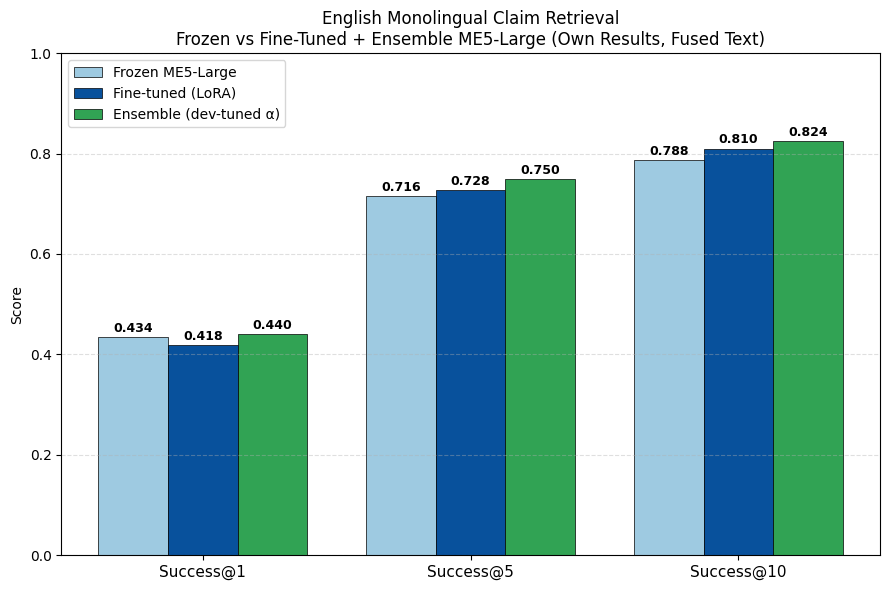

Saved chart to: /content/drive/MyDrive/semeval_august27neil_results/final_comparison/frozen_vs_finetuned_chart.png


In [ ]:
# ============================================================
# CELL 28: COMPARISON CHART — GROUPED BAR (own results, + ensemble if available)
# ============================================================
import matplotlib.pyplot as plt

metrics = ['success@1', 'success@5', 'success@10']
has_ensemble = 'results_ensemble' in globals()

fig, ax = plt.subplots(figsize=(9, 6))
x = np.arange(3)

frozen_vals = [results_frozen_fused[m] for m in metrics]
finetuned_vals = [results_finetuned[m] for m in metrics]

if has_ensemble:
    ensemble_vals = [results_ensemble[m] for m in metrics]
    width = 0.26
    bars1 = ax.bar(x - width, frozen_vals, width, label='Frozen ME5-Large', color='#9ECAE1', edgecolor='black', linewidth=0.5)
    bars2 = ax.bar(x, finetuned_vals, width, label='Fine-tuned (LoRA)', color='#08519C', edgecolor='black', linewidth=0.5)
    bars3 = ax.bar(x + width, ensemble_vals, width, label='Ensemble (dev-tuned α)', color='#31A354', edgecolor='black', linewidth=0.5)
    all_bars = [bars1, bars2, bars3]
else:
    width = 0.32
    bars1 = ax.bar(x - width/2, frozen_vals, width, label='Frozen ME5-Large', color='#9ECAE1', edgecolor='black', linewidth=0.5)
    bars2 = ax.bar(x + width/2, finetuned_vals, width, label='Fine-tuned (LoRA)', color='#08519C', edgecolor='black', linewidth=0.5)
    all_bars = [bars1, bars2]

for bars in all_bars:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.01, f'{h:.3f}', ha='center', fontsize=9, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(['Success@1', 'Success@5', 'Success@10'], fontsize=11)
ax.set_ylabel('Score')
ax.set_ylim(0, 1.0)
title_suffix = ' + Ensemble' if has_ensemble else ''
ax.set_title(f'English Monolingual Claim Retrieval\nFrozen vs Fine-Tuned{title_suffix} ME5-Large (Own Results, Fused Text)', fontsize=12)
ax.legend(loc='upper left')
ax.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
chart_path = os.path.join(results_output_dir, 'frozen_vs_finetuned_chart.png')
plt.savefig(chart_path, dpi=200, bbox_inches='tight')
plt.show()
print(f'Saved chart to: {chart_path}')

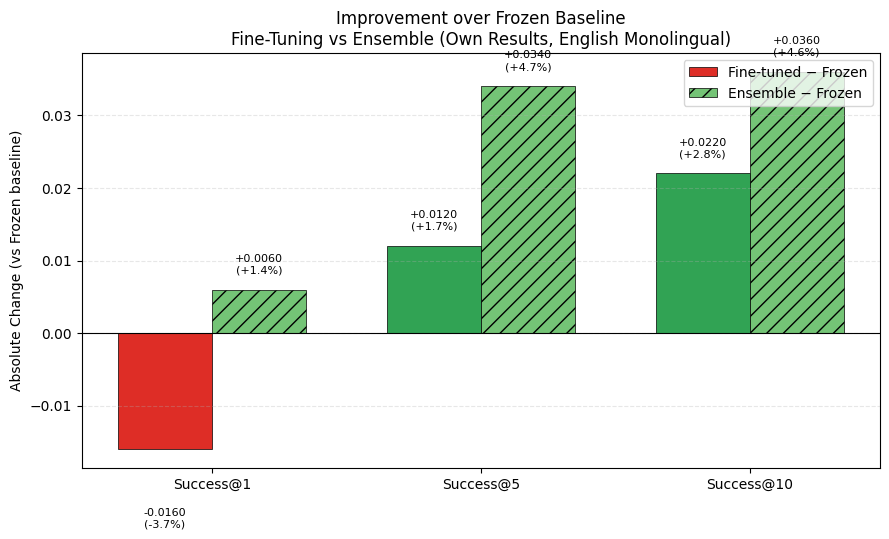

Saved chart to: /content/drive/MyDrive/semeval_august27neil_results/final_comparison/improvement_delta_chart.png


In [ ]:
# ============================================================
# CELL 29: IMPROVEMENT DELTA CHART — Fine-tuned vs Ensemble (both vs Frozen baseline)
# ============================================================
metrics_labels = ['Success@1', 'Success@5', 'Success@10']
has_ensemble = 'results_ensemble' in globals()

ft_deltas = [improvement[m] for m in metrics]
ft_pct = [pct_improvement[m] for m in metrics]

fig, ax = plt.subplots(figsize=(9, 5.5))
x = np.arange(3)

if has_ensemble:
    ens_improvement = {m: results_ensemble[m] - results_frozen_fused[m] for m in metrics}
    ens_pct = {m: (ens_improvement[m] / results_frozen_fused[m]) * 100 for m in metrics}
    ens_deltas = [ens_improvement[m] for m in metrics]

    width = 0.35
    bars_ft = ax.bar(x - width/2, ft_deltas, width, label='Fine-tuned − Frozen',
                      color=['#31A354' if d >= 0 else '#DE2D26' for d in ft_deltas],
                      edgecolor='black', linewidth=0.5)
    bars_ens = ax.bar(x + width/2, ens_deltas, width, label='Ensemble − Frozen',
                       color=['#74C476' if d >= 0 else '#FC9272' for d in ens_deltas],
                       edgecolor='black', linewidth=0.5, hatch='//')

    for bars, vals, pcts in [(bars_ft, ft_deltas, ft_pct), (bars_ens, ens_deltas, [ens_pct[m] for m in metrics])]:
        for bar, val, pct in zip(bars, vals, pcts):
            y_pos = val + 0.002 if val >= 0 else val - 0.008
            ax.text(bar.get_x() + bar.get_width()/2, y_pos, f'{val:+.4f}\n({pct:+.1f}%)',
                    ha='center', va='bottom' if val >= 0 else 'top', fontsize=8)

    ax.set_xticks(x)
    ax.set_xticklabels(metrics_labels)
    ax.legend(loc='upper right')
    title = 'Improvement over Frozen Baseline\nFine-Tuning vs Ensemble (Own Results, English Monolingual)'
else:
    colors_delta = ['#31A354' if d >= 0 else '#DE2D26' for d in ft_deltas]
    bars = ax.bar(metrics_labels, ft_deltas, color=colors_delta, edgecolor='black', linewidth=0.5)
    for bar, val, pct in zip(bars, ft_deltas, ft_pct):
        y_pos = val + 0.002 if val >= 0 else val - 0.008
        ax.text(bar.get_x() + bar.get_width()/2, y_pos, f'{val:+.4f}\n({pct:+.1f}%)',
                ha='center', va='bottom' if val >= 0 else 'top', fontsize=9)
    title = 'Improvement from LoRA Fine-Tuning\n(Own Results, English Monolingual)'

ax.axhline(y=0, color='black', linewidth=0.8)
ax.set_ylabel('Absolute Change (vs Frozen baseline)')
ax.set_title(title, fontsize=12)
ax.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
delta_chart_path = os.path.join(results_output_dir, 'improvement_delta_chart.png')
plt.savefig(delta_chart_path, dpi=200, bbox_inches='tight')
plt.show()
print(f'Saved chart to: {delta_chart_path}')